#### Experiments: Dataset Analysis

Visual and exploratory analysis of the synthetic datasets used throughout the project. The objective is to understand the statistical properties of the generated demand patterns and explain the behavior of the forecasting and optimization components in controlled scenarios. The insights obtained from these analyses will support the interpretation of the experimental results and will be incorporated into the main paper.

In [1]:
# Fundamental imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from pathlib import Path
dataset_folder = Path("../datasets/synthetic_v1/")

In [22]:
# Raw data imports, from synthetic_1 (used dataset in experimentation)
raw_origins = pd.read_parquet(dataset_folder / 'origins.parquet')
print(raw_origins.shape)
raw_origins.head()

(3, 2)


,origin_id,daily_capacity
0,O01,88
1,O02,157
2,O03,145


In [23]:
raw_destination = pd.read_parquet(dataset_folder / 'destinations.parquet')
print(raw_destination.shape)
raw_destination

(6, 2)


,destination_id,holding_cost
0,D01,1.79
1,D02,1.55
2,D03,0.64
3,D04,1.96
4,D05,1.64
5,D06,1.68


In [24]:
raw_lanes = pd.read_parquet(dataset_folder / 'lanes.parquet')
print(raw_lanes.shape)
raw_lanes.head()

(18, 3)


,origin_id,destination_id,unit_cost
0,O01,D01,13.0
1,O01,D02,15.0
2,O01,D03,7.0
3,O01,D04,21.0
4,O01,D05,14.0


In [31]:
raw_demand = pd.read_parquet(dataset_folder / 'demand_history.parquet')
print(raw_demand.shape)
print(raw_demand.head())
print(raw_demand.groupby("destination_id").size())

(1086, 3)
        date destination_id  demand
0 2025-01-01            D01   44.28
1 2025-01-02            D01   46.45
2 2025-01-03            D01   45.73
3 2025-01-04            D01   41.59
4 2025-01-05            D01   41.91
destination_id
D01    181
D02    181
D03    181
D04    181
D05    181
D06    181
dtype: int64


We have exactly 6 months of daily data for each destination. I will plot here the demand time series now.

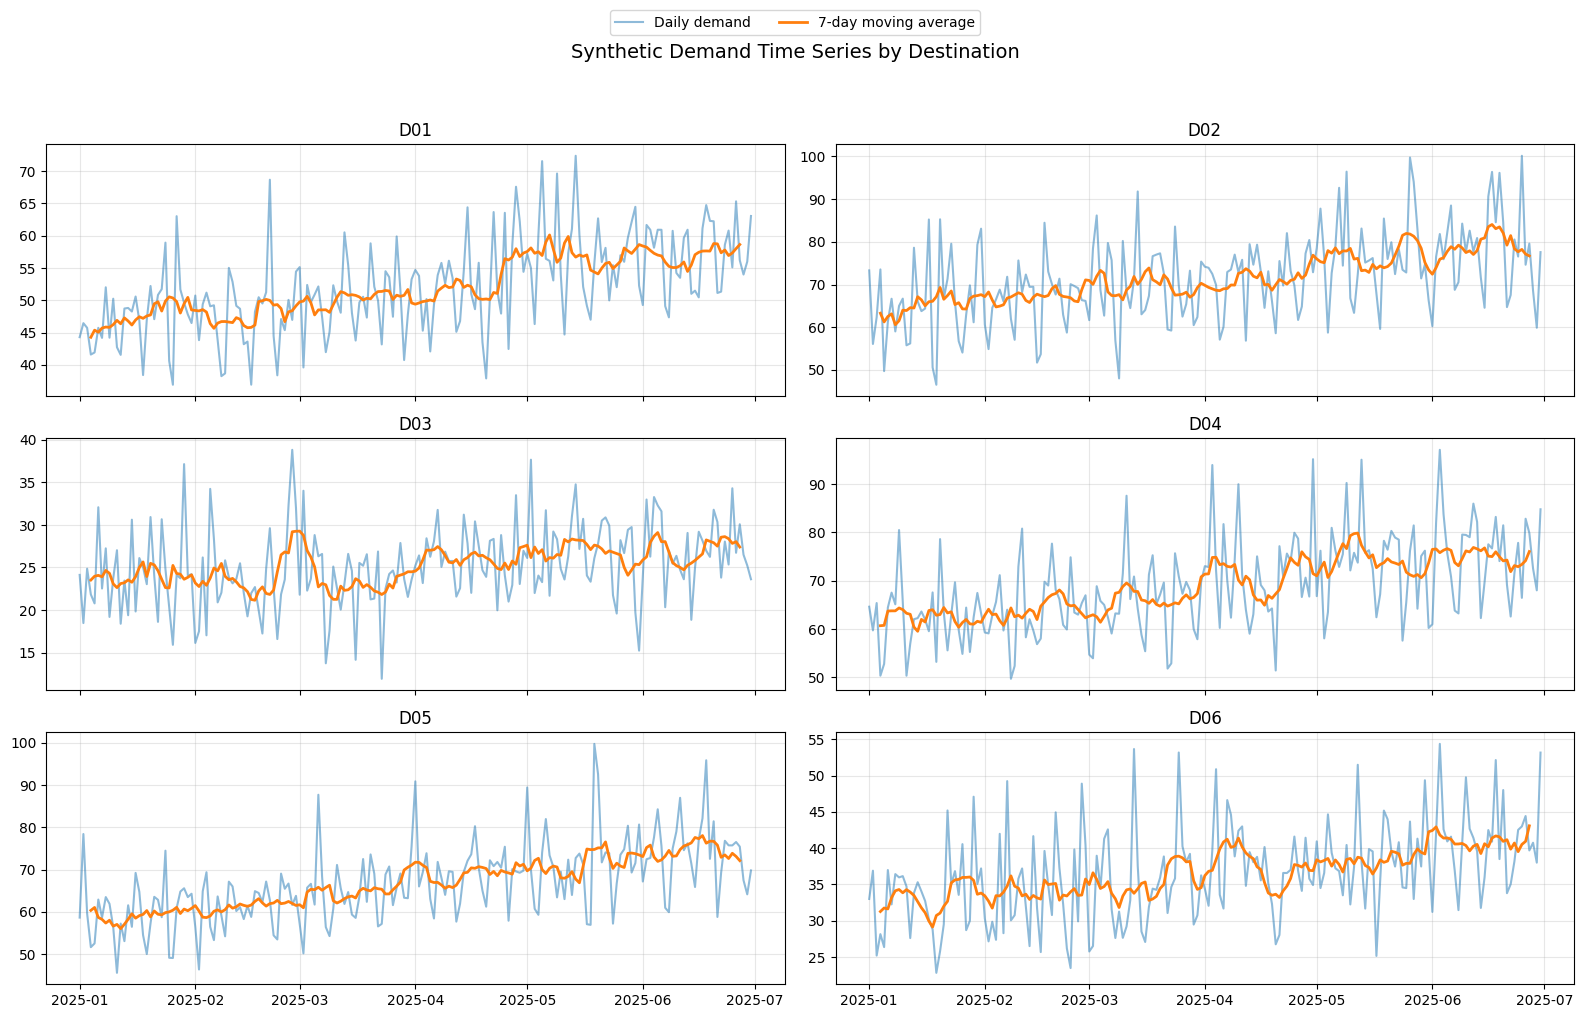

In [36]:
# plotting here the demand timereseis, as well as the 7 days movign average plots
raw_demand["date"] = pd.to_datetime(raw_demand["date"])

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 10),
    sharex=True,
)

axes = axes.flatten()

for ax, destination_id in zip(
    axes,
    sorted(raw_demand["destination_id"].unique())
):

    df_dest = (
        raw_demand[raw_demand["destination_id"] == destination_id]
        .sort_values("date")
        .copy()
    )

    # 7-day moving average
    df_dest["ma7"] = (
        df_dest["demand"]
        .rolling(window=7, center=True)
        .mean()
    )

    ax.plot(
        df_dest["date"],
        df_dest["demand"],
        alpha=0.5,
        label="Daily demand"
    )

    ax.plot(
        df_dest["date"],
        df_dest["ma7"],
        linewidth=2,
        label="7-day moving average"
    )

    ax.set_title(destination_id)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Synthetic Demand Time Series by Destination",
    fontsize=14
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()